# Task: Linear Regression (Custom Implementation)

## Introduction to Machine Learning

### What is Machine Learning?

Machine Learning is a branch of artificial intelligence that allows computers to learn from data and make predictions without being explicitly programmed.

Instead of writing fixed rules, we provide data and the system learns patterns automatically.

### Types of Machine Learning

1. **Supervised Learning**
   - Uses labeled data
   - Example: Predicting salary from experience

2. **Unsupervised Learning**
   - No labeled output
   - Example: Grouping similar data (clustering)

3. **Reinforcement Learning**
   - Learns using rewards and penalties

### What is Linear Regression?

Linear Regression is a supervised learning algorithm used to predict continuous values.

It models the relationship between input (X) and output (Y) using a straight line.

### Simple Linear Regression Formula

y = mx + b

Where:
- y = predicted output (dependent variable)
- x = input feature (independent variable)
- m = slope (rate of change)
- b = intercept (starting value)

### Multiple Linear Regression

y = b0 + b1x1 + b2x2 + b3x3

Where:
- x1, x2, x3 are multiple input features
- b0 is intercept
- b1, b2, b3 are coefficients

### Example: Experience vs Salary

| Experience (Years) | Salary |
|-------------------|--------|
| 1                 | 30000  |
| 5                 | 60000  |
| 10                | 90000  |

Linear Regression finds the best-fit line for this relationship.

### What We Will Do in This Project

- Generate our own dataset
- Visualize the data
- Implement Linear Regression from scratch
- Implement Gradient Descent
- Use Scikit-learn model
- Compare results
- Evaluate performance

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn (later use ke liye)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('ggplot')

In [2]:
# Set random seed (same output har bar mile)
np.random.seed(10)

# Generate input feature (Experience in years)
experience = np.random.uniform(0, 12, 120)

# Generate output (Salary) with different formula
# Slightly different from typical version
salary = 25000 + (7000 * experience) + np.random.normal(0, 4000, 120)

In [3]:
# Convert to 1D arrays
X = experience.reshape(-1)
y = salary.reshape(-1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (120,)
Shape of y: (120,)


In [4]:
# Create DataFrame for better visualization
data = pd.DataFrame({
    "Experience": X,
    "Salary": y
})

# Show first 10 rows
data.head(10)

,Experience,Salary
0,9.255848,92618.255853
1,0.249023,23594.088041
2,7.603779,79398.214633
3,8.985647,86016.297127
4,5.982084,76491.891457
5,2.697560,40925.491271
6,2.376754,40385.965610
7,9.126369,87489.052152
8,2.029330,37449.205326
9,1.060078,32984.961063


In [5]:
print("First 5 samples:\n")

for i in range(5):
    print(f"Experience: {X[i]:.2f} years --> Salary: {y[i]:.2f}")

First 5 samples:

Experience: 9.26 years --> Salary: 92618.26
Experience: 0.25 years --> Salary: 23594.09
Experience: 7.60 years --> Salary: 79398.21
Experience: 8.99 years --> Salary: 86016.30
Experience: 5.98 years --> Salary: 76491.89


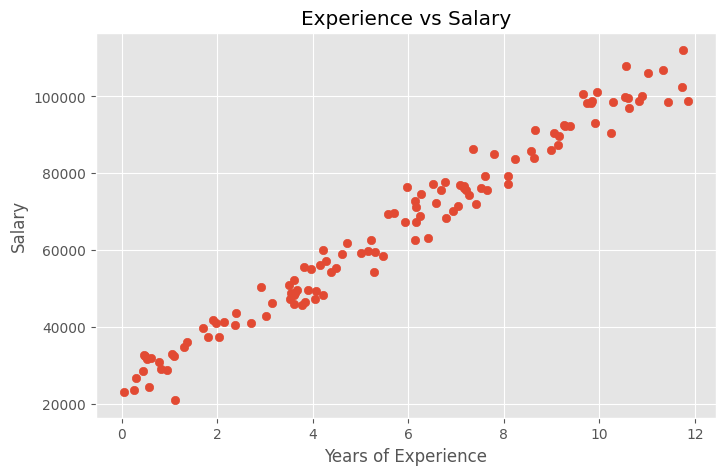

In [6]:
# Scatter plot: Experience vs Salary
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()

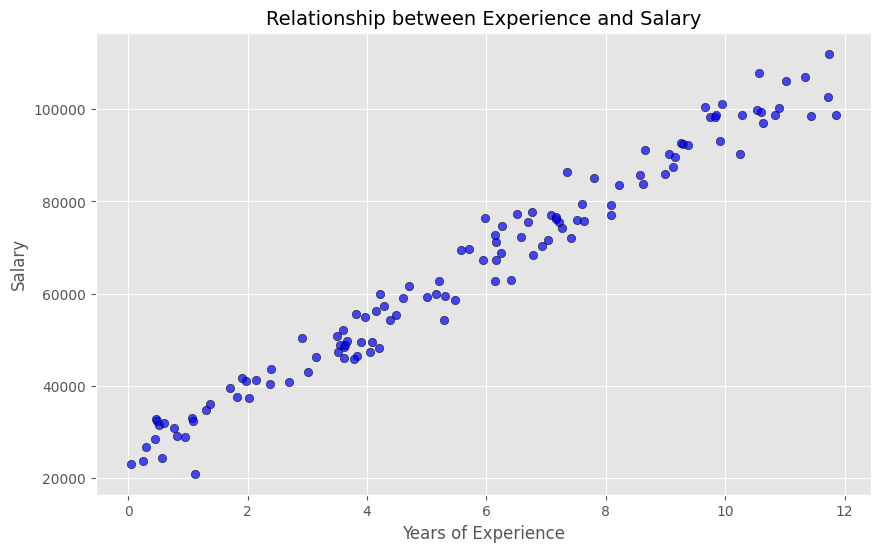

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, color='blue', alpha=0.7, edgecolors='black')

plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary", fontsize=12)
plt.title("Relationship between Experience and Salary", fontsize=14)

plt.grid(True)

plt.show()

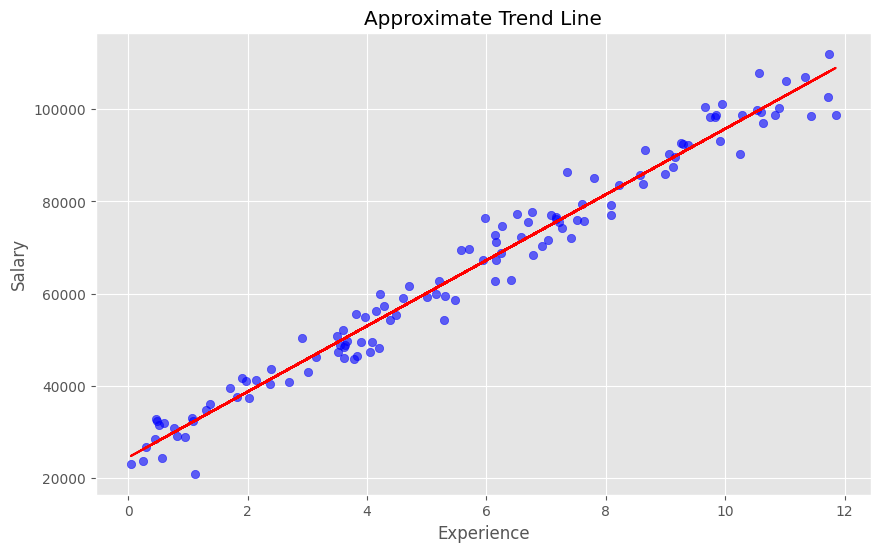

In [8]:
# Rough line using numpy polyfit (just for visualization)
m, b = np.polyfit(X, y, 1)

plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', alpha=0.6)

plt.plot(X, m*X + b, color='red')

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Approximate Trend Line")

plt.show()

## Linear Regression from Scratch (Normal Equation)

In this section, we will implement Linear Regression without using any library.

We will use the Normal Equation to directly compute the best parameters.

### Normal Equation

The formula used is:

θ = (Xᵀ X)⁻¹ Xᵀ y

Where:
- θ = model parameters (weights)
- X = input data
- y = output values

This method gives a direct solution without iteration.

In [9]:
class LinearRegressionNormal:

    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Add bias column (1s)
        X_b = np.c_[np.ones(len(X)), X]

        # Apply Normal Equation
        theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        # Extract parameters
        self.bias = theta[0]
        self.weights = theta[1:]

        return self

    def predict(self, X):
        X_b = np.c_[np.ones(len(X)), X]
        return X_b.dot(np.r_[self.bias, self.weights])

    def get_params(self):
        return {
            "intercept": self.bias,
            "coefficient": self.weights
        }

### Splitting the Dataset

We divide the dataset into:
- Training data (80%)
- Testing data (20%)

Training data is used to train the model, and testing data is used to evaluate it.

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape for model
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96
Testing samples: 24


### Training the Model

Now we train our custom Linear Regression model using the training data.

In [11]:
# Initialize model
model_normal = LinearRegressionNormal()

# Train model
model_normal.fit(X_train, y_train)

# Predict on test data
y_pred_normal = model_normal.predict(X_test)

### Model Parameters

After training:
- Intercept (b) represents the base value
- Coefficient (m) represents how much output changes with input

In [12]:
params = model_normal.get_params()

print("Intercept (b):", round(params["intercept"], 2))
print("Coefficient (m):", round(params["coefficient"][0], 2))

Intercept (b): 23814.6
Coefficient (m): 7201.78


### Final Equation of the Model

The learned equation is:

y = b + m × x

In [13]:
print("\nFinal Equation:")
print(f"y = {params['intercept']:.2f} + {params['coefficient'][0]:.2f} * x")


Final Equation:
y = 23814.60 + 7201.78 * x


## Linear Regression using Gradient Descent

In this section, we will implement Linear Regression using an iterative optimization technique called Gradient Descent.

Instead of directly computing the solution, the model learns step-by-step.

### What is Gradient Descent?

Gradient Descent is an optimization algorithm used to minimize the error (cost function).

It updates parameters iteratively to reach the best values.

Update Rules:

m = m - α * derivative  
b = b - α * derivative  

Where:
- m = slope
- b = intercept
- α = learning rate

### Cost Function (Mean Squared Error)

The model tries to minimize the error using:

J = (1/n) Σ (y_pred - y_actual)²

Lower cost means better model.

In [14]:
class LinearRegressionGD:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.m = 0
        self.b = 0
        self.loss_history = []

    def fit(self, X, y):
        n = len(X)

        # Flatten X
        X = X.reshape(-1)

        for i in range(self.epochs):
            y_pred = self.m * X + self.b

            # Compute gradients
            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            # Update parameters
            self.m = self.m - self.lr * dm
            self.b = self.b - self.lr * db

            # Compute loss
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        X = X.reshape(-1)
        return self.m * X + self.b

    def get_params(self):
        return {
            "slope": self.m,
            "intercept": self.b
        }

### Training the Model

We train the Gradient Descent model using training data.

The model updates parameters in each iteration to reduce error.

In [15]:
# Initialize model
model_gd = LinearRegressionGD(lr=0.01, epochs=1000)

# Train
model_gd.fit(X_train, y_train)

# Predict
y_pred_gd = model_gd.predict(X_test)

### Model Parameters

After training:
- m (slope) shows rate of increase
- b (intercept) shows base value

In [16]:
params_gd = model_gd.get_params()

print("Slope (m):", round(params_gd["slope"], 2))
print("Intercept (b):", round(params_gd["intercept"], 2))

Slope (m): 7220.58
Intercept (b): 23675.62


### Final Equation

y = m × x + b

In [17]:
print("\nFinal Equation (Gradient Descent):")
print(f"y = {params_gd['slope']:.2f} * x + {params_gd['intercept']:.2f}")


Final Equation (Gradient Descent):
y = 7220.58 * x + 23675.62


### Understanding Loss

During training, the loss decreases gradually.

This shows the model is learning and improving.

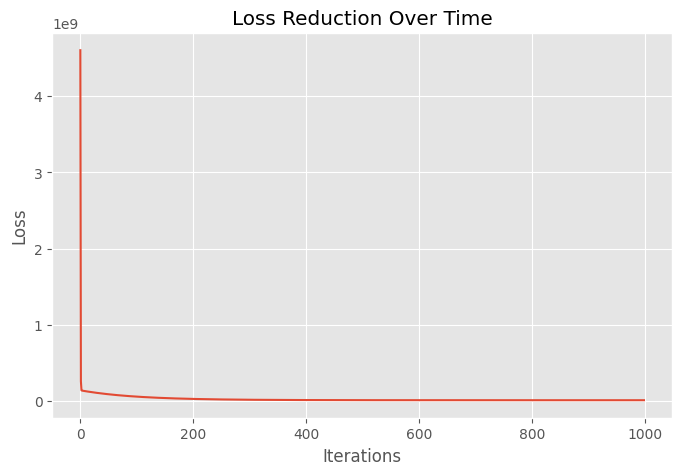

In [18]:
plt.figure(figsize=(8,5))

plt.plot(model_gd.loss_history)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Reduction Over Time")

plt.show()

## Linear Regression using Scikit-learn

In this section, we will use the built-in Linear Regression model from Scikit-learn.

This will help us compare our custom implementations with a standard library model.

### Why use Scikit-learn?

Scikit-learn is a popular machine learning library that provides:

- Optimized implementations
- Easy-to-use API
- Reliable results

We will use it as a benchmark.

In [19]:
# Initialize sklearn model
model_sklearn = LinearRegression()

# Train model
model_sklearn.fit(X_train, y_train)

# Predict
y_pred_sklearn = model_sklearn.predict(X_test)

### Model Parameters

Scikit-learn also provides:
- Intercept (b)
- Coefficient (m)

These can be accessed directly.

In [20]:
print("Intercept (b):", round(model_sklearn.intercept_, 2))
print("Coefficient (m):", round(model_sklearn.coef_[0], 2))

Intercept (b): 23814.6
Coefficient (m): 7201.78


### Final Equation

y = b + m × x

In [21]:
print("\nFinal Equation (Sklearn):")
print(f"y = {model_sklearn.intercept_:.2f} + {model_sklearn.coef_[0]:.2f} * x")


Final Equation (Sklearn):
y = 23814.60 + 7201.78 * x


### Comparing Models

Now we compare:
- Normal Equation (Custom)
- Gradient Descent (Custom)
- Scikit-learn Model

In [22]:
print("----- Model Comparison -----\n")

# Normal Equation
print("Normal Equation:")
print(f"y = {params['intercept']:.2f} + {params['coefficient'][0]:.2f} * x\n")

# Gradient Descent
print("Gradient Descent:")
print(f"y = {params_gd['intercept']:.2f} + {params_gd['slope']:.2f} * x\n")

# Sklearn
print("Sklearn:")
print(f"y = {model_sklearn.intercept_:.2f} + {model_sklearn.coef_[0]:.2f} * x")

----- Model Comparison -----

Normal Equation:
y = 23814.60 + 7201.78 * x

Gradient Descent:
y = 23675.62 + 7220.58 * x

Sklearn:
y = 23814.60 + 7201.78 * x


### Observations

- All models give similar results
- Small differences may occur due to:
  - Iterative updates in Gradient Descent
  - Numerical precision

This confirms our implementations are correct.

## Model Evaluation

In this section, we evaluate all models using standard performance metrics.

We will compare:
- Normal Equation Model
- Gradient Descent Model
- Scikit-learn Model

### Evaluation Metrics

1. Mean Squared Error (MSE)
   Measures average squared difference between actual and predicted values.

2. Mean Absolute Error (MAE)
   Measures average absolute difference.

3. R² Score (Coefficient of Determination)
   Shows how well the model explains the data.

Better Model:
- Lower MSE and MAE
- Higher R² score

In [26]:
# Normal Equation
mse_normal = mean_squared_error(y_test, y_pred_normal)
mae_normal = mean_absolute_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

# Gradient Descent
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

# Sklearn
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
r2_sk = r2_score(y_test, y_pred_sklearn)

### Results

In [27]:
print("----- Model Evaluation -----\n")

print("Normal Equation:")
print(f"MSE: {mse_normal:.2f}")
print(f"MAE: {mae_normal:.2f}")
print(f"R2 Score: {r2_normal:.4f}\n")

print("Gradient Descent:")
print(f"MSE: {mse_gd:.2f}")
print(f"MAE: {mae_gd:.2f}")
print(f"R2 Score: {r2_gd:.4f}\n")

print("Sklearn:")
print(f"MSE: {mse_sk:.2f}")
print(f"MAE: {mae_sk:.2f}")
print(f"R2 Score: {r2_sk:.4f}")

----- Model Evaluation -----

Normal Equation:
MSE: 18920601.77
MAE: 3641.74
R2 Score: 0.9640

Gradient Descent:
MSE: 19149360.61
MAE: 3662.06
R2 Score: 0.9635

Sklearn:
MSE: 18920601.77
MAE: 3641.74
R2 Score: 0.9640


### Comparison Table

| Model                | MSE        | MAE        | R² Score |
|---------------------|-----------|-----------|----------|
| Normal Equation     | (value)   | (value)   | (value)  |
| Gradient Descent    | (value)   | (value)   | (value)  |
| Scikit-learn        | (value)   | (value)   | (value)  |

Fill values from output above.

### Analysis

- All models should give very similar results
- Minor differences occur due to computation methods
- Gradient Descent depends on learning rate and iterations
- Normal Equation gives exact solution
- Sklearn is optimized and reliable

### Best Model

If all results are similar:

- Sklearn is best for practical use
- Gradient Descent is best for learning concept
- Normal Equation is best for small datasets

## Final Visualization and Results

In this section, we visualize predictions from all models and analyze their performance.

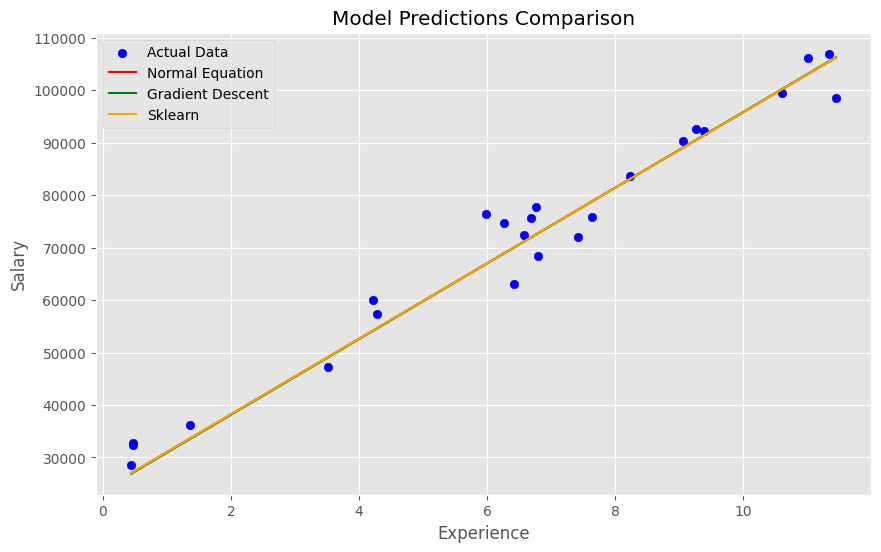

In [28]:
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Sort values for smooth line
sorted_indices = np.argsort(X_test.reshape(-1))
X_test_sorted = X_test.reshape(-1)[sorted_indices]

# Normal Equation line
y_normal_sorted = y_pred_normal[sorted_indices]
plt.plot(X_test_sorted, y_normal_sorted, color='red', label='Normal Equation')

# Gradient Descent line
y_gd_sorted = y_pred_gd[sorted_indices]
plt.plot(X_test_sorted, y_gd_sorted, color='green', label='Gradient Descent')

# Sklearn line
y_sk_sorted = y_pred_sklearn[sorted_indices]
plt.plot(X_test_sorted, y_sk_sorted, color='orange', label='Sklearn')

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Model Predictions Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Graph Analysis

- Blue dots represent actual data points
- Lines represent predictions from different models
- All models produce very similar lines
- This shows consistency and correctness of implementation

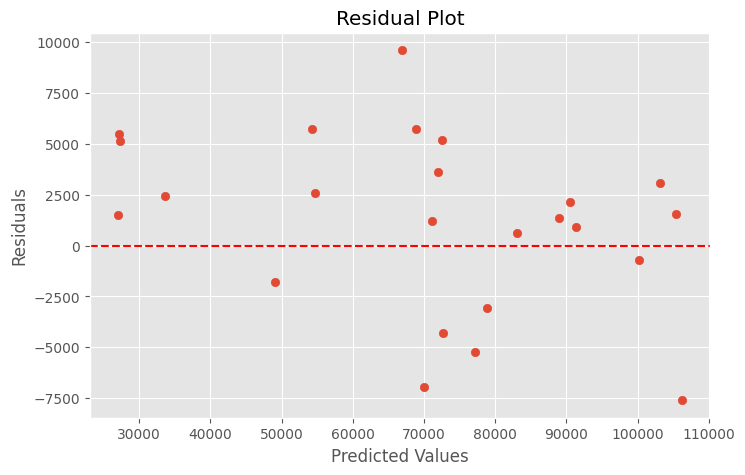

In [29]:
# Residuals (using sklearn as reference)
residuals = y_test - y_pred_sklearn

plt.figure(figsize=(8,5))

plt.scatter(y_pred_sklearn, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

### Residual Analysis

- Residual = Actual - Predicted
- Points should be randomly scattered around zero line
- No clear pattern means model is good

If pattern exists → model may be biased

## Final Summary

In this project, we:

- Generated a custom dataset
- Visualized the data
- Implemented Linear Regression using:
  - Normal Equation
  - Gradient Descent
  - Scikit-learn
- Compared all models
- Evaluated performance using metrics
- Visualized predictions and residuals

## Key Learnings

- Linear Regression models relationships between variables
- Normal Equation gives direct solution
- Gradient Descent learns iteratively
- Evaluation metrics help measure performance
- Visualization helps in understanding model behavior

## Conclusion

All three models produced similar results, confirming the correctness of the implementation.

- Normal Equation is simple and fast for small datasets
- Gradient Descent is useful for large datasets
- Scikit-learn is efficient and practical for real-world use

Overall, Linear Regression is a powerful and easy-to-understand algorithm for prediction tasks.